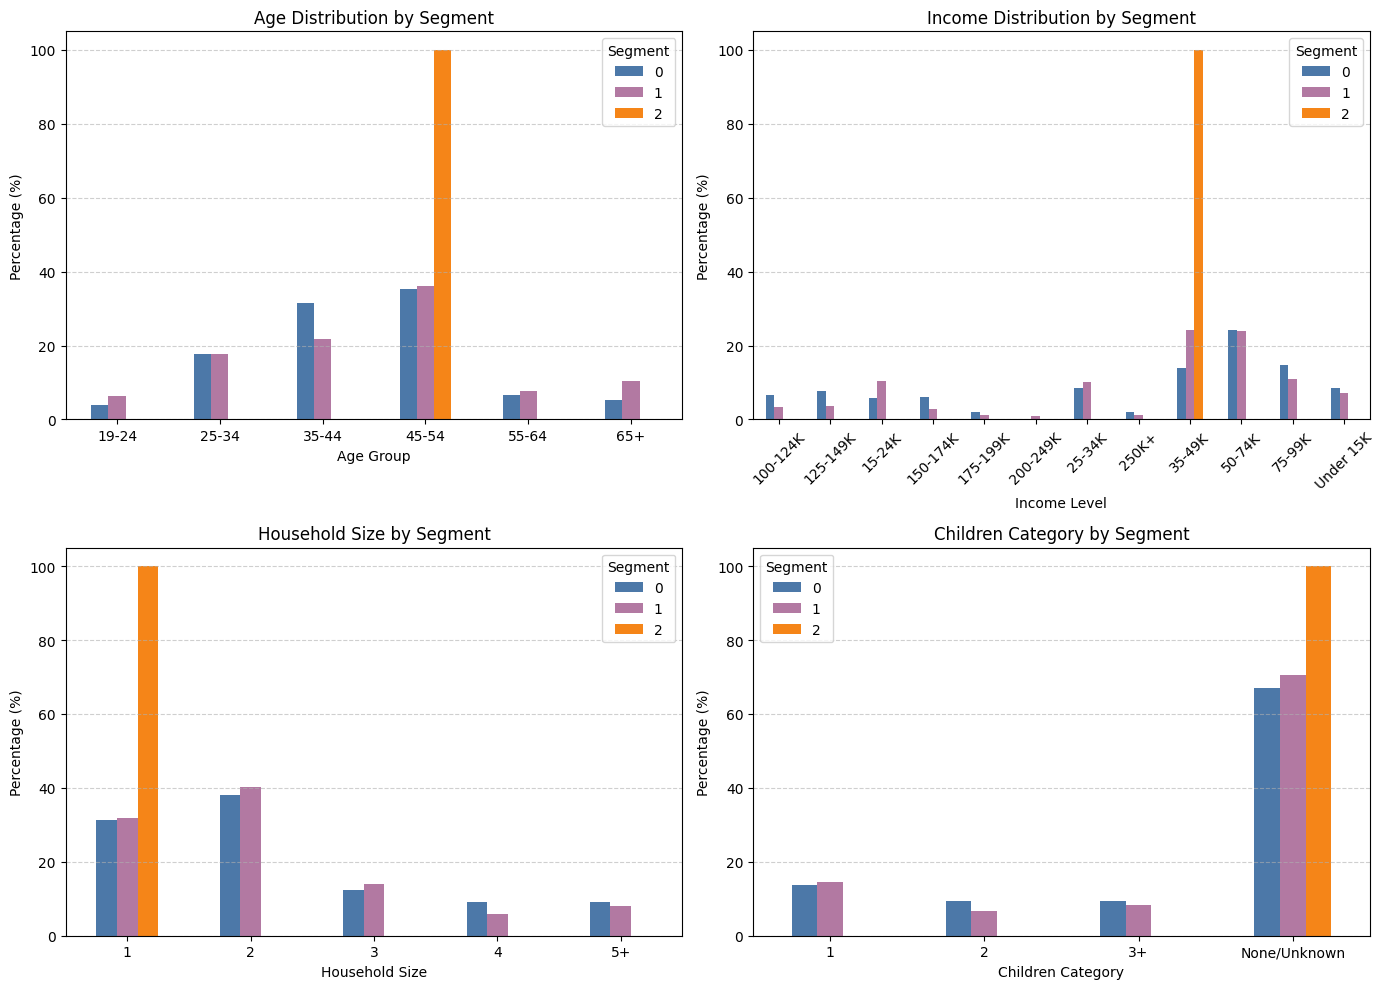

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Import datasets
age_profile = pd.read_csv("C:/Users/15195/Desktop/coding part/coding part/k-means-修改版/age_profile.csv", index_col=0)
income_profile = pd.read_csv("C:/Users/15195/Desktop/coding part/coding part/k-means-修改版/segment_income_profile.csv", index_col=0)
household_size_profile = pd.read_csv("C:/Users/15195/Desktop/coding part/coding part/k-means-修改版/household_size_profile.csv", index_col=0)
kid_profile = pd.read_csv("C:/Users/15195/Desktop/coding part/coding part/k-means-修改版/kid_profile.csv", index_col=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = ['#4C78A8', '#B279A2', '#F58518']
segments = ['Cluster 0', 'Cluster 1', 'Cluster 2']

# Age distribution
age_profile.T.plot(kind='bar', ax=axes[0,0], color=colors, rot=0)
axes[0,0].set_title('Age Distribution by Segment')
axes[0,0].set_xlabel('Age Group')
axes[0,0].set_ylabel('Percentage (%)')
axes[0,0].legend(title='Segment')
axes[0,0].grid(axis='y', linestyle='--', alpha=0.6)

# Income distribution
income_profile.T.plot(kind='bar', ax=axes[0,1], color=colors, rot=45)
axes[0,1].set_title('Income Distribution by Segment')
axes[0,1].set_xlabel('Income Level')
axes[0,1].set_ylabel('Percentage (%)')
axes[0,1].legend(title='Segment')
axes[0,1].grid(axis='y', linestyle='--', alpha=0.6)

# Household size distribution
household_size_profile.T.plot(kind='bar', ax=axes[1,0], color=colors, rot=0)
axes[1,0].set_title('Household Size by Segment')
axes[1,0].set_xlabel('Household Size')
axes[1,0].set_ylabel('Percentage (%)')
axes[1,0].legend(title='Segment')
axes[1,0].grid(axis='y', linestyle='--', alpha=0.6)

# Kids distribution
kid_profile.T.plot(kind='bar', ax=axes[1,1], color=colors, rot=0)
axes[1,1].set_title('Children Category by Segment')
axes[1,1].set_xlabel('Children Category')
axes[1,1].set_ylabel('Percentage (%)')
axes[1,1].legend(title='Segment')
axes[1,1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('demographic_grouped_bars.png', dpi=300, bbox_inches='tight')
plt.show()

cluster cluster  recency  frequency  monetary  total_quantity  \
0             0  -0.3655     1.2353    1.2681          2.3510   
1             1  -0.2296     0.2044    0.2583         -0.2586   
2             2   0.8766    -1.2501   -1.4285         -0.4387   

cluster  average_basket_size  category_diversity  
0                     0.0980              0.9098  
1                     0.2035              0.3311  
2                    -0.6603             -1.4617  


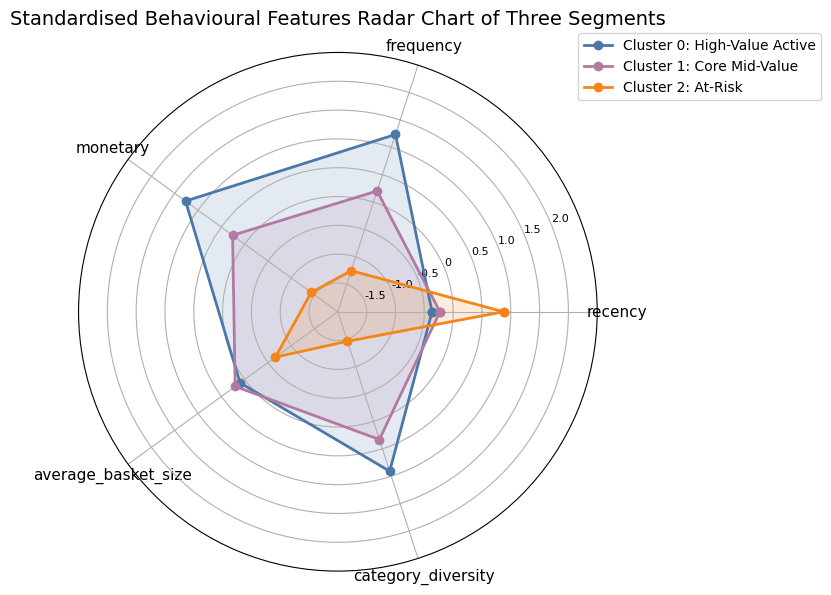

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

standardised_segment_profile = pd.read_csv("C:/Users/15195/Desktop/coding part/coding part/k-means-修改版/standardised_segment_profile.csv")

standardised_segment_profile = (
    standardised_segment_profile
    .set_index('cluster')
    .T
    .reset_index()
    .rename(columns={'index': 'cluster'})
)
print(standardised_segment_profile)

# Select features
features_for_radar = [
    'recency',
    'frequency',
    'monetary',
    'average_basket_size',
    'category_diversity'
]

segments = standardised_segment_profile['cluster'].values
n_features = len(features_for_radar)

# Calculate the angles 
angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
angles += angles[:1]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Define color and label
colors = ['#4C78A8', '#B279A2', '#F58518']
segment_labels = ['Cluster 0: High-Value Active', 
                  'Cluster 1: Core Mid-Value', 
                  'Cluster 2: At-Risk']

for i, seg in enumerate(segments):
    values = standardised_segment_profile[
        standardised_segment_profile['cluster'] == seg
    ][features_for_radar].iloc[0].tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, 
            color=colors[i], label=segment_labels[i])
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features_for_radar, fontsize=11)
ax.set_ylim(-2, 2.5)
ax.set_yticks([-1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5, 2.0])
ax.set_yticklabels(['-1.5', '-1.0', '-0.5', '0', '0.5', '1.0', '1.5', '2.0'], fontsize=8)

plt.title('Standardised Behavioural Features Radar Chart of Three Segments', 
          fontsize=14, pad=20)
plt.legend(loc='upper left', bbox_to_anchor=(0.95, 1.05))

plt.tight_layout()
plt.savefig('figure_radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()